# **Model-2: LFCC-LCNN using A-Softmax Loss and FreqAugment**

## **Imports**


In [1]:
import os
import glob
import torchaudio
import torchaudio.transforms as T
import torch
import librosa
import librosa.display
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.metrics import confusion_matrix, f1_score, roc_curve,auc
import scipy
from scipy.optimize import brentq 
from scipy.interpolate import interp1d

## **Main Configuration**

In [2]:
# --- Main Configuration ---
DATASET_BASE_DIR = '/kaggle/input/asvspoof-2019-la/ASVspoof2019_LA_wav'
PRECOMPUTED_BASE_DIR = '/kaggle/working/precomputed_lfcc'
TRAIN_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'train')
DEV_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'dev')
EVAL_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'eval')

MODEL_SAVE_PATH = 'LFCC_LCNN_ASoftmax_FreqAug.pth'

# Create output directories
os.makedirs(TRAIN_OUTPUT_DIR, exist_ok=True)
os.makedirs(DEV_OUTPUT_DIR, exist_ok=True)
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

# --- Paths ---
TRAIN_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.train.trn.txt')
DEV_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.dev.trl.txt')
EVAL_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.eval.trl.txt')

TRAIN_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_train', 'flac')
DEV_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_dev', 'flac')
EVAL_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_eval', 'flac')

# --- Feature Parameters ---
SAMPLE_RATE = 16000
N_LFCC = 20 # Number of static coefficients
N_FEATURES = N_LFCC * 3 # 20 static + 20 delta + 20 delta-delta = 60
MAX_FRAMES = 600
WIN_LENGTH = int(0.020 * SAMPLE_RATE) # 320 samples
HOP_LENGTH = int(0.010 * SAMPLE_RATE) # 160 samples

# ---Other Parameters ---
NUM_CLASSES=2

# **LFCC Feature Extraction**

In [3]:
def extract_lfcc(audio_path, target_sr=SAMPLE_RATE):
    """
    Extracts 60-dimensional LFCC features following the Lavrentyeva et al. (2019)
    methodology for the ASVspoof 2019 challenge, using torchaudio.

    Args:
        audio_path (str): Path to the audio file.
        target_sr (int): Target sample rate. The ASVspoof 2019 dataset is 16 kHz.

    Returns:
        torch.Tensor: LFCC features with shape (1, 60, num_frames).
    """
    try:
        waveform, sample_rate = torchaudio.load(audio_path)
    except Exception as e:
        print(f"Error loading {audio_path}: {e}")
        return None
        
    if sample_rate != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)
        waveform = resampler(waveform)
    
    # Convert to single channel and apply pre-emphasis
    waveform = waveform.mean(dim=0, keepdim=True)
    preemphasis_filter = T.Preemphasis(coeff=0.97)
    waveform = preemphasis_filter(waveform)

    # Compute LFCCs
    lfcc_transform = T.LFCC(
        sample_rate=target_sr,
        n_lfcc=N_LFCC,
        speckwargs={
            'n_fft': 512,
            'win_length': WIN_LENGTH,
            'hop_length': HOP_LENGTH,
            'power': 2.0
        }
    )
    lfccs = lfcc_transform(waveform)

    # Compute delta and delta-delta
    delta = T.ComputeDeltas(win_length=3)(lfccs)
    delta2 = T.ComputeDeltas(win_length=3)(delta)

    # Concatenate static, delta, and delta-delta
    full_lfccs = torch.cat((lfccs, delta, delta2), dim=1) # dim=1 to concatenate coefficients
    
    return full_lfccs

def process_and_save(file_path, audio_id, label, output_dir):
    """
    Loads audio, extracts LFCC features, and saves them to a .pt file.
    """
    try:
        # Extract features using the dedicated function
        lfcc_features = extract_lfcc(file_path)
        if lfcc_features is None:
            return None, None

        # Pad or truncate to MAX_FRAMES
        num_frames = lfcc_features.shape[2]  # Shape is (1,60,600)
        if num_frames > MAX_FRAMES:
            start_frame = (num_frames - MAX_FRAMES) // 2
            lfcc_features = lfcc_features[:, :, start_frame : start_frame + MAX_FRAMES]
        elif num_frames < MAX_FRAMES:
            padding = MAX_FRAMES - num_frames
            padding_left = padding // 2
            padding_right = padding - padding_left
            lfcc_features = torch.nn.functional.pad(lfcc_features, (padding_left, padding_right), "constant", 0)

        # Input shape from extract_lfcc is (1, 60, 600)
        # Transpose to (frames, features, channels)==(600, 60, 1) and unsqueeze channel dim
        lfcc_features = lfcc_features.squeeze(0).T.unsqueeze(-1)
        
        # Save the tensor and label
        file_info = {
            'features': lfcc_features.to(torch.float16),
            'label': torch.tensor(label, dtype=torch.long)
        }
        
        out_path = os.path.join(output_dir, audio_id + '.pt')
        torch.save(file_info, out_path)
        
        return audio_id, label
    except Exception as e:
        print(f"Error with {file_path}: {e}")
        return None, None

def parse_protocol(protocol_file, audio_dir):
    """
    Parses protocol file and returns a list of tuples (file_path, audio_id, label).
    """
    file_info = []
    if not os.path.exists(protocol_file):
        print(f"Warning: Protocol file not found: {protocol_file}")
        return file_info
    
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split(' ')
            if len(parts) >= 5:
                audio_file_id = parts[1]
                file_path = os.path.join(audio_dir, audio_file_id + '.wav')
                if os.path.exists(file_path):
                    label = 1 if parts[4].lower() == 'spoof' else 0
                    file_info.append((file_path, audio_file_id, label))
                else:
                    print(f"Warning: Audio file not found: {file_path}")
            
    return file_info

def batch_extract_and_save(protocol_path, audio_dir, output_dir):
    """
    Main function to process and save a full dataset split in parallel.
    """
    print(f"Starting processing for {output_dir}...")
    file_info = parse_protocol(protocol_path, audio_dir)
    
    results = Parallel(n_jobs=-1)(
        delayed(process_and_save)(path, audio_id, label, output_dir)
        for path, audio_id, label in tqdm(file_info, desc=f"Saving to {output_dir}")
    )
    
    label_map = {audio_id: label for audio_id, label in results if audio_id is not None}
    label_path = os.path.join(output_dir, 'labels.pt')
    torch.save(label_map, label_path)
    
    print(f"Finished. Saved {len(label_map)} features and labels to: {output_dir}")


# Precomputation of LFCC features, saved to working directory as .pt files

if not os.path.exists(TRAIN_OUTPUT_DIR) or not os.listdir(TRAIN_OUTPUT_DIR):
    print("Precomputing training features...")
    batch_extract_and_save(TRAIN_PROTOCOL, TRAIN_AUDIO_DIR, TRAIN_OUTPUT_DIR)
else:
    print("Training features already precomputed.")

if not os.path.exists(DEV_OUTPUT_DIR) or not os.listdir(DEV_OUTPUT_DIR):
    print("Precomputing development features...")
    batch_extract_and_save(DEV_PROTOCOL, DEV_AUDIO_DIR, DEV_OUTPUT_DIR)
else:
    print("Development features already precomputed.")

if not os.path.exists(EVAL_OUTPUT_DIR) or not os.listdir(EVAL_OUTPUT_DIR):
    print("Precomputing evaluation features...")
    batch_extract_and_save(EVAL_PROTOCOL, EVAL_AUDIO_DIR, EVAL_OUTPUT_DIR)
else:
    print("Evaluation features already precomputed.")

Training features already precomputed.
Development features already precomputed.
Evaluation features already precomputed.


# **Model Definition**

## **Max-Feature-Map Activation and LCNN Model**

In [4]:
# Max Feature Map
class MaxFeatureMap(nn.Module):
    """
    Max-Feature-Map (MFM) activation layer for Conv layers.
    Splits along the channel dimension.
    """
    def __init__(self):
        super(MaxFeatureMap, self).__init__()
        
    def forward(self, x):
        # Splits the input tensor along the channel dimension (dim=1)
        x1, x2 = torch.split(x, x.size(1) // 2, dim=1)
        return torch.max(x1, x2)


# LCNN 
class LCNN(nn.Module):
    def __init__(self, sample_input_shape):
        super(LCNN, self).__init__()
        
        self.mfm = MaxFeatureMap()

        # --- LCNN Body (Convolutional Layers) ---
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(5, 5), padding='same')
        self.mp1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv4 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv7 = nn.Conv2d(32, 96, kernel_size=(3, 3), padding='same')
        self.mp2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.bn2 = nn.BatchNorm2d(48)
        self.conv11 = nn.Conv2d(48, 96, kernel_size=(1, 1), padding='same')
        self.bn3 = nn.BatchNorm2d(48)
        self.conv14 = nn.Conv2d(48, 128, kernel_size=(3, 3), padding='same')
        self.mp3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv17 = nn.Conv2d(64, 128, kernel_size=(1, 1), padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.conv20 = nn.Conv2d(64, 64, kernel_size=(3, 3), padding='same')
        self.bn5 = nn.BatchNorm2d(32)
        self.conv23 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn6 = nn.BatchNorm2d(32)
        self.conv26 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding='same')
        self.mp4 = nn.MaxPool2d(kernel_size=(2, 2))

         # --- Dynamic Calculation of Input Size for Linear Layer ---
        dummy_input = torch.randn(1, 1, *sample_input_shape[:2])
        conv_output = self._forward_conv(dummy_input)
        flattened_size = conv_output.reshape(1, -1).size(1)
        print(f"Dynamically calculated flattened size based on real data: {flattened_size}")

        # --- Fully Connected (Linear) Layers ---
        self.fc29 = nn.Linear(flattened_size, 160)
        self.bn7 = nn.BatchNorm1d(80)
        self.dropout = nn.Dropout(p=0.75)

    def _forward_conv(self, x):
        """A helper function to pass data through the conv layers."""
        # This logic is identical to the forward pass, used for shape calculation
        x = self.mfm(self.conv1(x))
        x = self.mp1(x)
        x = self.mfm(self.conv4(x))
        x = self.bn1(x)
        x = self.mfm(self.conv7(x))
        x = self.mp2(x)
        x = self.mfm(self.conv11(x))
        x = self.bn3(x) 
        x = self.mfm(self.conv14(x))
        x = self.mp3(x)
        x = self.mfm(self.conv17(x))
        x = self.bn4(x)
        x = self.mfm(self.conv20(x))
        x = self.bn5(x)
        x = self.mfm(self.conv23(x))
        x = self.bn6(x)
        x = self.mfm(self.conv26(x))
        x = self.mp4(x)
        return x

    def forward(self, x):
        # Pass through all the convolutional layers
        x = self._forward_conv(x)
        
        # Flatten the tensor before the linear layer
        x = x.reshape(x.size(0), -1)

        # Pass through the first linear layer
        x = self.fc29(x)
        
        # --- MFM for Linear Layer ---
        # Output of fc29 is (32, 160). reshape to (32, 2, 80)
        x = x.view(x.size(0), 2, -1) 
        # Then take the max along the new dimension (dim=1)
        x = torch.max(x, dim=1)[0] # Shape becomes (32, 80)

        x = self.bn7(x)
        embeddings = self.dropout(x)
        return embeddings

## **A-Softmax Layer**

In [5]:
class ASoftmax(nn.Module):
    """
    A-Softmax layer with a trainable weight matrix.
    
    SphereFace: Deep Hypersphere Embedding for Face Recognition (CVPR '17)
    Weiyang Liu, Yandong Wen, Zhiding Yu, Ming Li, Bhiksha Raj, Le Song
    https://arxiv.org/abs/1704.08063
    
    Sourced and adapted from: https://github.com/phillity/metric_learning/blob/master/losses/angular_margin_loss/sphereface_loss.py
    """
    def __init__(self, in_features, num_classes, scale=30.0, margin=1.35):
        super(ASoftmax, self).__init__()
        self.in_features = in_features
        self.num_classes = num_classes
        self.scale = scale
        self.margin = margin

        self.W = nn.Parameter(torch.Tensor(in_features, num_classes))
        nn.init.kaiming_uniform_(self.W, a=2)

    def forward(self, embeddings, labels=None):
        # Normalise weights and embeddings
        W_norm = F.normalize(self.W, p=2, dim=0)
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        
        # Calculate cosine similarity (logits for inference)
        cosine_logits = embeddings_norm.mm(W_norm)
    
        # If no labels are provided (during evaluation), return the raw logits
        if labels is None:
            return cosine_logits
    
        # --- Training Path ---
        theta = torch.acos(torch.clamp(cosine_logits, -1.0 + 1e-7, 1.0 - 1e-7))
        one_hot = torch.zeros_like(cosine_logits)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        phi = theta * self.margin
        target_logits = torch.cos(phi)
        
        output = (one_hot * target_logits) + ((1.0 - one_hot) * cosine_logits)
        output *= self.scale
        
        return output

# **Model Training**

In [6]:
class LFCCDataset(Dataset):
    def __init__(self, data_dir):
        #directory where .pt files are saved
        self.data_dir = data_dir
        # find all files matching ".pt" in the directory        
        self.file_list = glob.glob(os.path.join(data_dir, '*.pt'))
        # Exclude the labels.pt file (not a feature)
        self.file_list = [f for f in self.file_list if not os.path.basename(f).startswith('labels')]

    def __len__(self):
        # return num of samples in the dataset
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        # Load the dictionary saved with features and labels
        data = torch.load(file_path)
        # Extract the features tensor
        features = data['features']
        # Extract the label tensor
        label = data['label']
        # Return features and the label as a tuple
        return features.float(), label


#Check GPU Copmatibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# --- Data Loading ---
print("Loading datasets...")
train_dataset = LFCCDataset(TRAIN_OUTPUT_DIR)
dev_dataset = LFCCDataset(DEV_OUTPUT_DIR)
eval_dataset = LFCCDataset(EVAL_OUTPUT_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count())
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count())
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count())


# --- Model---
print("Creating LCNN model with A-Softmax...")
# Get the shape of a single sample from the dataset
sample_features, _ = train_dataset[0]
input_shape = sample_features.shape# The features have shape [600, 60, 1]
print(f"Sample input shape from dataset: {input_shape}")

# Define model 
lcnn_model = LCNN(input_shape).to(device)
a_softmax_layer = ASoftmax(in_features=80, num_classes=NUM_CLASSES).to(device)

Using device: cuda
Loading datasets...
Creating LCNN model with A-Softmax...
Sample input shape from dataset: torch.Size([600, 60, 1])
Dynamically calculated flattened size based on real data: 3552


In [7]:
# --- Loss and Optimizer ---
optimizer = optim.Adam(
    list(lcnn_model.parameters()) + list(a_softmax_layer.parameters()),
    lr = 0.0001
)
criterion = nn.CrossEntropyLoss()

# --- Training Loop ---
num_epochs = 50
best_val_loss = float('inf')
patience_counter = 0
patience = 15
train_accuracy_history = []
train_loss_history =[]
val_loss_history = []
val_accuracy_history = []

# --- Frequency Augmentation Transform ---
freq_mask_transform = T.FrequencyMasking(freq_mask_param = 3, iid_masks = False)

print("Starting training...")
for epoch in range(num_epochs):
    lcnn_model.train()
    a_softmax_layer.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for features, labels in tqdm(train_loader, desc = f"Epoch {epoch + 1}/{num_epochs} Training"):
        features, labels = features.to(device), labels.to(device)
    
        # Apply Frequency Masking on the batch
        # 1. Permute for torchaudio transform: (batch, 600, 60, 1) -> (batch, 1, 60, 600)
        features_permuted_for_torchaudio = features.permute(0, 3, 2, 1)
        features_masked = freq_mask_transform(features_permuted_for_torchaudio)

        # 2. Permute back for the LCNN model: (32, 1, 60, 600) -> (32, 1, 600, 60)
        features_for_model = features_masked.permute(0, 1, 3, 2)
        
        optimizer.zero_grad()
        
        # Forward pass: get embeddings from the LCNN using the augmented features
        embeddings = lcnn_model(features_for_model)
        
        # Get modified logits from the A-Softmax layer
        logits = a_softmax_layer(embeddings, labels)
        
        # Calculate the loss
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * features.size(0)
        # Calculate training accuracy for the batch
        # To get predictions, get the standard logits without the angular margin
        with torch.no_grad():
            logits_for_acc = a_softmax_layer(embeddings) 
            _, predicted = torch.max(logits_for_acc.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

    # Validation loop
    lcnn_model.eval()
    a_softmax_layer.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for features, labels in tqdm(dev_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation"):
            features, labels = features.to(device), labels.to(device)

            # Permute for the LCNN model in validation, no augmentation
            features_for_model = features.permute(0, 3, 1, 2)

            embeddings = lcnn_model(features_for_model)
            logits = a_softmax_layer(embeddings) 
            
            loss = criterion(logits, labels)
            val_loss += loss.item() * features.size(0)
            
            _, predicted = torch.max(logits.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate and print core metrics
    epoch_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = 100 * train_correct / train_total
    val_loss /= len(dev_dataset)
    val_accuracy = 100 * val_correct / val_total

    train_loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_train_accuracy)
    val_loss_history.append(val_loss)
    val_accuracy_history.append(val_accuracy)

    
    print(f'Epoch {epoch+1}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    # Early stopping and model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'lcnn_state_dict': lcnn_model.state_dict(),
            'a_softmax_state_dict': a_softmax_layer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
        }, 'LFCC_LCNN_asoftmax_freqaug.pth')
        print(f"Model saved to 'LFCC_LCNN_ASoftmax_FreqAug1.pth' with new best validation loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break
print("Training finished.")

Starting training...


Epoch 1/50 Validation: 100%|██████████| 777/777 [00:21<00:00, 35.46it/s]


Epoch 1: Train Loss: 6.4048, Train Acc: 80.11%, Val Loss: 0.4380, Val Acc: 89.57%
Model saved to 'LFCC_LCNN_ASoftmax_FreqAug1.pth' with new best validation loss: 0.4380


Epoch 2/50 Validation: 100%|██████████| 777/777 [00:21<00:00, 35.54it/s]


Epoch 2: Train Loss: 2.6609, Train Acc: 91.84%, Val Loss: 0.2766, Val Acc: 99.33%
Model saved to 'LFCC_LCNN_ASoftmax_FreqAug1.pth' with new best validation loss: 0.2766


...

Epoch 48: Train Loss: 0.0661, Train Acc: 99.85%, Val Loss: 0.1709, Val Acc: 99.98%


Epoch 49/50 Validation: 100%|██████████| 777/777 [00:22<00:00, 34.91it/s]


Epoch 49: Train Loss: 0.0525, Train Acc: 99.90%, Val Loss: 0.1731, Val Acc: 99.98%


Epoch 50/50 Validation: 100%|██████████| 777/777 [00:22<00:00, 34.93it/s]

Epoch 50: Train Loss: 0.0688, Train Acc: 99.84%, Val Loss: 0.1704, Val Acc: 99.98%
Model saved to 'LFCC_LCNN_ASoftmax_FreqAug1.pth' with new best validation loss: 0.1704
Training finished.


## **Training and Validation Plots**

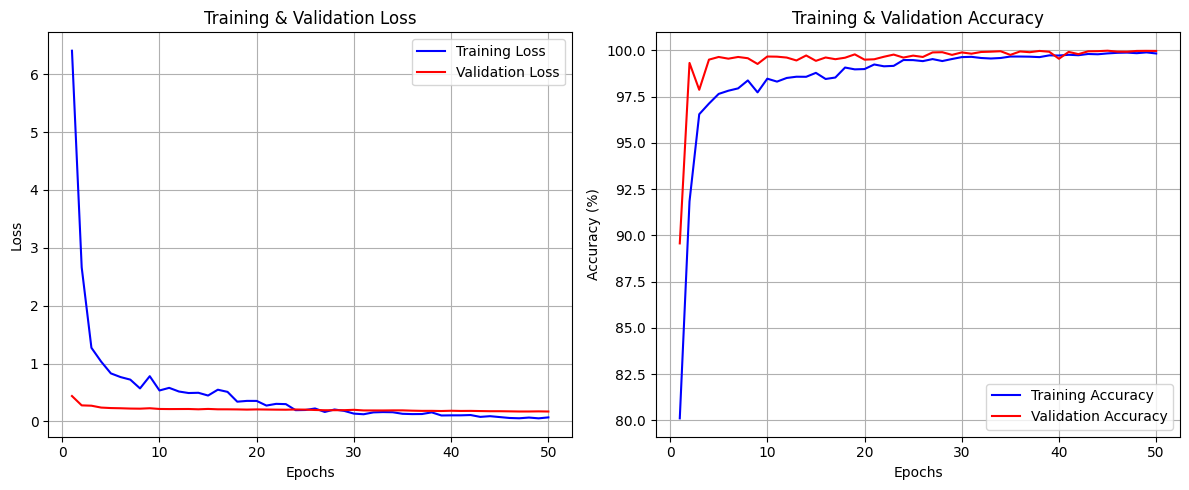

In [14]:
# Plotting the loss and accuracy curves
epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, 'b', label='Training Loss')
plt.plot(epochs, val_loss_history, 'r', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_history, 'b', label='Training Accuracy') # New line
plt.plot(epochs, val_accuracy_history, 'r', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Evaluating Model-2 on Development and Evaluation Sets**

In [9]:
# --- Data Loading for the Evaluation Set ---
print("Loading evaluation dataset...")
eval_dataset = LFCCDataset(EVAL_OUTPUT_DIR)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count())

# --- Model, Loss, and Optimizer ---
print("Creating LCNN model with A-Softmax (for loading best checkpoint)...")
# Get the shape of a single sample from the dataset (to ensure it matches the training data)
sample_features, _ = train_dataset[0] 
sample_input_shape = sample_features.shape

# Create LCNN model and ASoftmax layer instances (these will be overwritten by the loaded checkpoint)
lcnn_model = LCNN(sample_input_shape).to(device)
a_softmax_layer = ASoftmax(in_features=80, num_classes=NUM_CLASSES).to(device)

# --- Final Evaluation Step ---
print("\n--- Starting Final Evaluation on Evaluation Set ---")

# Load the best model states
try:
    checkpoint = torch.load('LFCC_LCNN_ASoftmax1.pth')
    lcnn_model.load_state_dict(checkpoint['lcnn_state_dict'])
    a_softmax_layer.load_state_dict(checkpoint['a_softmax_state_dict'])
    print("Loaded best model from 'LFCC_LCNN_ASoftmax1.pth'.")
except FileNotFoundError:
    print("Error: Model checkpoint 'LFCC_LCNN_ASoftmax1.pth' not found. Please ensure it exists.")
    exit()

# Set models to evaluation mode
lcnn_model.eval()
a_softmax_layer.eval()

# Run final evaluation
val_labels_list = []
val_preds_list = []
val_scores_list = []

with torch.no_grad():
    for features, labels in tqdm(eval_loader, desc="Final Evaluation on Eval Set"):
        features, labels = features.to(device), labels.to(device)
        features_for_model = features.permute(0, 3, 1, 2)
        embeddings = lcnn_model(features_for_model)
        logits = a_softmax_layer(embeddings) 
        
        _, predicted = torch.max(logits.data, 1)
        val_labels_list.extend(labels.cpu().numpy())
        val_preds_list.extend(predicted.cpu().numpy())
        
        softmax_scores = F.softmax(logits, dim=1)
        val_scores_list.extend(softmax_scores[:, 1].cpu().numpy())

# Calculate and print the overall metrics
cm = confusion_matrix(val_labels_list, val_preds_list)
f1 = f1_score(val_labels_list, val_preds_list)
fpr, tpr, _ = roc_curve(val_labels_list, val_scores_list, pos_label=1)
eer = fpr[np.argmin(np.abs(fpr - (1 - tpr)))]
eer = eer * 100
print("\n--- Final Model Performance on Evaluation Set ---")
print(f"Confusion Matrix:\n{cm}")
print(f"F1 Score: {f1:.4f}")
print(f"Equal Error Rate (EER): {eer:.2f}%")
print("-" * 50)

Loading evaluation dataset...
Creating LCNN model with A-Softmax (for loading best checkpoint)...
Dynamically calculated flattened size based on real data: 3552

--- Starting Final Evaluation on Evaluation Set ---
Loaded best model from 'LFCC_LCNN_ASoftmax1.pth'.


Final Evaluation on Eval Set: 100%|██████████| 2227/2227 [01:03<00:00, 35.02it/s]



--- Final Model Performance on Evaluation Set ---
Confusion Matrix:
[[ 7318    37]
 [20372 43510]]
F1 Score: 0.8100
Equal Error Rate (EER): 9.16%
--------------------------------------------------


# **Plots**


### **ROC Curve plot**

In [10]:
def plot_roc_curve(results, model_name="Model-2"):
    """
    Plots the ROC curve using the results from the evaluate_model function.
    
    Args:
        results (dict): The dictionary returned by evaluate_model.
        model_name (str): A name for the model/dataset for the plot title.
    """
    # Get the fpr and tpr from the results dictionary
    fpr = results['fpr']
    tpr = results['tpr']
    
    # Compute Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

### **Feature Visualisation Function**

In [11]:
def display_augmented_samples(feature_dir, num_samples=3, freq_mask_param=2):
    """
    Loads, augments, and displays LFCC features for random samples side-by-side,
    with an explicit black bar showing where the frequency mask was applied.

    Args:
        feature_dir (str): Path to the directory containing saved .pt feature files.
        num_samples (int): The number of random samples to display.
        freq_mask_param (int): The maximum width of the frequency mask.
    """
    all_files = [f for f in os.listdir(feature_dir) if f.endswith('.pt') and not f.startswith('labels')]
    if len(all_files) < num_samples:
        print(f"Warning: Only found {len(all_files)} files. Displaying all of them.")
        num_samples = len(all_files)
    if not all_files:
        print(f"No feature files found in {feature_dir}.")
        return

    selected_files = random.sample(all_files, num_samples)
    freq_mask_transform = T.FrequencyMasking(freq_mask_param=freq_mask_param, iid_masks=True)

    fig, axes = plt.subplots(num_samples, 2, figsize=(15, 5 * num_samples), squeeze=False)
    fig.suptitle('Original vs. Augmented LFCC Features', fontsize=18)

    for i, file_name in enumerate(selected_files):
        file_path = os.path.join(feature_dir, file_name)
        try:
            data = torch.load(file_path)
            features = data['features']
            label = data['label'].item()
            
            # Squeeze to (Time, LFCC_Coeffs)
            features_sq = features.squeeze(2)
            features_np = features_sq.numpy()
            
            # --- 1. Plot the Original Features ---
            ax_orig = axes[i, 0]
            im_orig = librosa.display.specshow(
                features_np.T, # Transpose for librosa plotting (60, 600)
                x_axis='frames',
                ax=ax_orig,
                cmap='magma'
            )
            title_color = 'red' if label == 1 else 'green'
            ax_orig.set_title(f'Sample {os.path.basename(file_path)} (Original) - {"Spoof" if label == 1 else "Bonafide"}', color=title_color)
            ax_orig.set_xlabel('Frames')
            ax_orig.set_ylabel('LFCC Coefficient')
            fig.colorbar(im_orig, ax=ax_orig, label='Amplitude')

            # --- 2. Augment and Plot the Masked Features ---
            ax_aug = axes[i, 1]
            
            # Prepare tensor for torchaudio, which needs (32, 1, 60, 600)
            features_for_transform = features_sq.T.unsqueeze(0).unsqueeze(0)
            
            # Create a clone to detect the mask later
            features_clone = features_for_transform.clone()

            # Apply frequency masking
            features_masked = freq_mask_transform(features_for_transform)
            augmented_features_np = features_masked.squeeze().numpy()

            # Normalise color mapping consistently
            vmin = np.min([features_np, augmented_features_np.T])
            vmax = np.max([features_np, augmented_features_np.T])
            norm = Normalize(vmin=vmin, vmax=vmax)
            
            # Plot the augmented features
            im_aug = librosa.display.specshow(
                augmented_features_np,
                x_axis='frames',
                ax=ax_aug,
                cmap='magma',
                norm=norm
            )
            
            # --- Overlay the black bar for the frequency mask ---
            # Detect where the tensor values were changed by the mask
            # compare the modified tensor to the original one.
            diff_mask = (features_clone != features_masked).squeeze() # Shape (freq, time)
            
            # Check if any frequency bins were masked
            if diff_mask.sum() > 0:
                masked_freq_bins = torch.where(diff_mask.sum(dim=1) > 0)[0]
                if masked_freq_bins.numel() > 0:
                    start_freq_bin = masked_freq_bins.min().item()
                    mask_height = masked_freq_bins.numel()

                    # Overlay a black rectangle
                    rect = patches.Rectangle(
                        (0, start_freq_bin), # Bottom-left corner
                        augmented_features_np.shape[1], # Width in time frames
                        mask_height, # Height in freq bins
                        linewidth=0,
                        edgecolor='none',
                        facecolor='black',
                        alpha=0.6,
                        zorder=10 # Ensure rectangle is on top of the image
                    )
                    ax_aug.add_patch(rect)
                    ax_aug.set_title(f'Sample {os.path.basename(file_path)} (Augmented, Masked)', color='blue')
            else:
                ax_aug.set_title(f'Sample {os.path.basename(file_path)} (Augmented, No Mask)', color='blue')
            
            ax_aug.set_xlabel('Frames')
            ax_aug.set_ylabel('LFCC Coefficient')
            fig.colorbar(im_aug, ax=ax_aug, label='Amplitude')

        except Exception as e:
            print(f"Error processing or displaying features from {file_path}: {e}")
            axes[i, 0].set_title("Error")
            axes[i, 1].set_title("Error")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


# **Main Execution**

In [12]:
# --- Load Model and Run Evaluations ---
# Load the single best checkpoint
try:
    checkpoint_path = 'LFCC_LCNN_ASoftmax_FreqAug1.pth'
    checkpoint = torch.load(checkpoint_path)
    lcnn_model.load_state_dict(checkpoint['lcnn_state_dict'])
    a_softmax_layer.load_state_dict(checkpoint['a_softmax_state_dict'])
    print(f"Loaded best model from '{checkpoint_path}'.")
except FileNotFoundError:
    print(f"Error: Model checkpoint not found at '{checkpoint_path}'.")
    
    
# Evaluation for the Development set
dev_results = evaluate_model(
    lcnn_model, 
    a_softmax_layer, 
    dev_loader, 
    device, 
    dataset_name="Development Set"
)

# --- Evaluate and Plot for the Evaluation Set ---
eval_results = evaluate_model(
    lcnn_model, 
    a_softmax_layer, 
    eval_loader, 
    device, 
    dataset_name="Evaluation Set"
)

# Plot the results for the eval set
plot_roc_curve(eval_results, model_name="Model-2 on Eval Set")

Error: Model checkpoint not found at 'LFCC_LCNN_ASoftmax_FreqAug1.pth'.


NameError: name 'evaluate_model' is not defined

In [ ]:
display_augmented_samples(TRAIN_OUTPUT_DIR)